In [25]:
pip install torch transformers tqdm

Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModel

In [27]:
df = pd.read_csv("../dataset/protein_balanced.csv")

df_small = df.groupby("label").sample(n=5000, random_state=42)

df_small["label"].value_counts()

label
binding      5000
enzyme       5000
transport    5000
Name: count, dtype: int64

In [28]:
model_name = "facebook/esm2_t6_8M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(model_name)
esm_model = AutoModel.from_pretrained(model_name)

esm_model.eval()

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


EsmModel(
  (embeddings): EsmEmbeddings(
    (word_embeddings): Embedding(33, 320, padding_idx=1)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (rotary_embeddings): EsmRotaryEmbedding()
  (encoder): EsmEncoder(
    (layer): ModuleList(
      (0-5): 6 x EsmLayer(
        (attention): EsmAttention(
          (self): EsmSelfAttention(
            (query): Linear(in_features=320, out_features=320, bias=True)
            (key): Linear(in_features=320, out_features=320, bias=True)
            (value): Linear(in_features=320, out_features=320, bias=True)
          )
          (output): EsmSelfOutput(
            (dense): Linear(in_features=320, out_features=320, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (LayerNorm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
        )
        (intermediate): EsmIntermediate(
          (dense): Linear(in_features=320, out_features=1280, bias=True)
        )
        (output): EsmOutput(
          (dens

In [29]:
def get_embedding(sequence):
    inputs = tokenizer(sequence, return_tensors="pt", truncation=True, max_length=512)
    
    with torch.no_grad():
        outputs = esm_model(**inputs)
    
    # take mean of last hidden states
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
    
    return embedding

In [30]:
X_embeddings = []
y_labels = []

for seq, label in tqdm(zip(df_small["sequence"], df_small["label"]), total=len(df_small)):
    emb = get_embedding(seq)
    X_embeddings.append(emb)
    y_labels.append(label)

X_embeddings = np.array(X_embeddings)
y_labels = np.array(y_labels)

print("Shape:", X_embeddings.shape)

100%|████████████████████████████████████████████████████████████████████████████| 15000/15000 [22:28<00:00, 11.12it/s]

Shape: (15000, 320)


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings,
    y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

model_esm = SVC(kernel="linear", probability=True)

model_esm.fit(X_train, y_train)

y_pred = model_esm.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     binding       0.91      0.95      0.93      1000
      enzyme       0.96      0.92      0.94      1000
   transport       0.94      0.94      0.94      1000

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000



In [32]:
import joblib

joblib.dump(model_esm, "../models/final_esm_model.pkl")

['../models/final_esm_model.pkl']

In [33]:
joblib.dump(tokenizer, "../models/esm_tokenizer.pkl")
joblib.dump(esm_model, "../models/esm_model_base.pkl")

['../models/esm_model_base.pkl']

In [37]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Create label encoder
label_encoder = LabelEncoder()

# Fit encoder on your labels
y_encoded = label_encoder.fit_transform(y_labels)

# Save encoder
joblib.dump(label_encoder, "../models/label_encoder.pkl")

print("Label encoder saved successfully!")
print("Classes:", label_encoder.classes_)
print("Encoded labels shape:", y_encoded.shape)

Label encoder saved successfully!
Classes: ['binding' 'enzyme' 'transport']
Encoded labels shape: (15000,)


In [11]:
def predict_with_esm(sequence):
    sequence = sequence.upper().replace(" ", "").replace("\n", "")

    inputs = tokenizer(
        sequence,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = esm_model(**inputs)

    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
    embedding = embedding.reshape(1, -1)

    prediction = model_esm.predict(embedding)[0]

    probabilities = model_esm.predict_proba(embedding)[0]
    confidence = max(probabilities) * 100

    return prediction, round(confidence, 2)

In [12]:
new_seq = "MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHF"

pred, conf = predict_with_esm(new_seq)

print("Prediction:", pred)
print("Confidence:", conf, "%")

Prediction: binding
Confidence: 87.87 %


In [13]:
new_seq = """QNHVQSYEPLPYCHNITYPGLGKPTREGALSKMGACINSIFFTFWAMPAIPLFNQIINCN
RLRCCSSLADLFKIVEDFMLFLRQGPFRKCGDQAGPLLMWINDNAVDYWFMAQKFIIEMH
AFDQIQMTNLTFVWNENHGLKVRLHKCGASNVDDNPEEHEMQRETGYWMFQGILVVIRMW
MQRYLWMKSGLWTKVIIPRPSDQGNYMRIATWEPYGSTLNNWARFRRRPQCPMFAKIDRR
GQLYAWTYNILNGDMRHYANLPRHIANMHYEANISRWRSEYQVIYHKKKPRGPQNFIAFW
EELPPRMFFLKFDSINSQFHYKPCVPCYTACQAYNEIYSQACAKLLWIMLPTELQQSTMA
FCFTWVEVLQYLHNIQETSTQNDAADMWVTDTCNANFDQHLNSAEQLGDWYGETCVWNAF
CHTEDNQMNKRNINRGAVWAASYTNFLTESMSMCPKTVWSDASGIVQSTPPHHIDNEIFL
GYSKHVRTGIQGEQEWHHVLRHAQQPDEIMFCMFEHYLIFPRDRYDWQNIRMCQHRVKNH
DRCMHLQQCLRISMGRNQIEPYLVSFMETYQKRKVPSLWVKYWRIMRLNLYYEIQQCFMA
KITGHAAMWSECPIKHVMAQYARHKQKEKNTIGYQYGQDYHNHHAGQRPFTDSWDCIAEL
YQLRSTWCQPSSYWWENYTNYWWQKAALFMAIPGLPMMTQHATTQLHNWAWRDWTLDTPQ
WSCQLQQEKNVNQIILYEMYNEDVMIEVRVEHVWLWCHGAWKPEMACWIARDTQLTESGY
AFRNKEPKMKHWEWWYANIFIQIMQPVWCQMACDNIWNHSWMWWDENILDHFYARSEIVQ
FPIKGEKAFSEWMGSYTSSIQDREYVCHLQPTTGFMECSFELATYAFPSKLSRSCEQVCI
FLPTDATFFGKMSTGWAKLQTHGWHTPHMRSQVAPAPKNKPIIDLSPTFMYHNAFSPTAC
PQRAPNEHWMCWDNLSRIINWQEDYMGATMPREGCDQLME"""

pred, conf = predict_with_esm(new_seq)

print("Prediction:", pred)
print("Confidence:", conf, "%")

Prediction: transport
Confidence: 40.19 %


In [14]:
new_seq = """LLGTDASTGDGPRQMRTCLPEYDEGIQPCPYRCYRSIEDPGISVTIEENFHMHMKKLTAE
KMKIDSGDPWRIIEDTQYYRYHIESDMVQTPDPNIQMEWMMHIHLQQRWHDKGCISQFFE
KCFAYWICWYFQVCVVKAWTMDAVNIIFGCPVCEPANDCNQAKSLAMGDYEEHCPPQWHG
KLLKPEFEYFDNWFTNARGMCATMDMYTSMHRANVEEFACLQQCLCFHWHSEKMKRFLTN
KATKARPGCTDTKSVLFWYICWPWADHFYRAAWEYHQAAVVYPFSDLWKAQHNCYWKFEV
DWMSRLNDDNVDCMSVQQIWLMMLCDAAHVWSPSVLSHLLEATVQDLYYQNPCLHIMDGE
SQMAHTFAKWWMMLGNHQCYGEMIKRGWMYIFSSPQERPRCSQYKTRQHVQAYWKIVPVD
QREDGAMNNNKICGCMWTNKHRKILIACIHDFTKWAKTTHCATQYDDWNYHEFPPATREC
PDYTAMDECECCCQLKQTLDQDLQYFDMQAEWYMNLLPSMCRKMEKRPVMPWWYEFCTQP
IYVTLIDERCMTQKDGWKNDFNNWWKPVYMLEVTCRQPEKVCFKALNFVPQDYINPESIC
TLQFKKSFAMIYGSLKTRYQGYCLTICACMTFDVLETRHGVKDFATKRMQVEGPRAWHGA
MLAGSKETCQMQFTCRWRMISPKLICWDNKVMNHRMTCWANYDLWDAWTWYMQFPERWTR
MRHRNTFPKFHNKIPNYTTETHQRDNTMSAWQYDLRWRAVVQPMEFFRNETGWVPMQYAL
ASLILKEGFYYFLCTNIHRQIACWLMGLCWTPAQECLLDWWIYANYMNAKTTNPSATRHW
RCLDSNKALNMTKIRIMACGVYDPGVVITMAERMLNIQVGGQEFGLNDQNYWKMYKHKPL
WTNWIYTELHTFACAFQSPQIQWRVYWCYHQKVRQCWAPCWMEYVNVPMTHYYINGIWKT
GEYLIYMHRLGCASPPTCASTGNGFIYDFVLGYDRFMYKSFCLGTPNHGRYCSWRSEDNR
CRRCYSILTHQVRADIYVGFSENFMWKWYREYGVMCFEVYSSEGENPMEQMFIYHRNLNS
PGWDINRPNDACTSVCHIKAFAWRGHQVDVDVDPQTCMIMQTQHKHHKVADRPVGEEARF
RACRHLVWKPKDVKTGDNRISEMNIHLYYIHNSLHGTRKMPLRIQEDNDCKGRIALEQRY
YQSMRVHHNKHVNLYRCQFSHCYWHVSILSQPSCTDWWEDFWATTDRNTEFASFGQDDVI
TRRWPVDCHLAKIDWNLTWCYTPSPFSEFGVLHVRYSNECQTACIWHSMIQYASKLMELI
QMFNKIMVNSGEEFYAMELIQMRLMGGPAADGTNMMNEQDPNQTMALPFHKLQYVKRSMV
DAKEETYSPWVRGTISRYMWGICFTFLWVQMVIDMKSPWNECDLFHGRSGRYFKGEYKTV
PMWTMHCYFMADDNIHTYVSYSQIYQAYKRRADTSIEMSMSHYWGFCIADIWMEEQTECS
FNFDFCWYKSWYQCSPNIFCDPMNPPDQCFAKHICFSPMSGIGPNADQPCMFQLMEYKSF
NERSPMTKRILYIPGYNPYDCIACENILKDYVPKGCVYHNWRYCGVSHRTYYLTDVRQLI
MHPFEGTDEKFGHTVDCATGVSESCKVDMRDEGKHFPMMFVMGCPSDCGVALHINQKSVM
KYVCNSFMDRIHNGDQKNQSGNMMWVFARSDTHIPNFGDEMDQFWFRPEDLSFWMGFWHG
YVVDYIPARWHARYFIDFVQVSQTEFRIQGHIDSFHGMQWTNAQHYAGHIRIPFNYFFPC
TPWAPMFHPEWQTHCVELGNDWHMEVQCENEQTDLLSDMYGLIDHYIQYDWATCRKVWVW
KITCANKADMGIHWDTKDTHDWEPCSQDFPVCMFGPCGGVLRWHCIVDDIDHMVQNMLYL
SQFHFMGWEQQSHREADCMGKATTHEVGHENWDGRGFNQFFDWQKYCTQPKEEFKKFGSK
KYEVEVMMHATMWFGMGMSP"""

pred, conf = predict_with_esm(new_seq)

print("Prediction:", pred)
print("Confidence:", conf, "%")

Prediction: transport
Confidence: 60.49 %


In [15]:
new_seq = "RNNPWWTFHMRKNNPHNIIQ"
pred, conf = predict_with_esm(new_seq)

print("Prediction:", pred)
print("Confidence:", conf, "%")

Prediction: enzyme
Confidence: 85.33 %


In [16]:
import pandas as pd

comparison = {
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Random Forest",
        "TF-IDF + SVM",
        "ESM + SVC (1500 samples)",
        "ESM + SVC (9000 samples)",
        "ESM + SVC (15000 samples)"
    ],
    
    "Accuracy": [
        0.90,   # your TF-IDF LR
        0.88,   # your RF
        0.91,   # your SVM
        0.88,   # ESM (1500)
        0.93,   # ESM (9000)
        0.94    # ESM (15000)
    ],
    
    "Type": [
        "Classical ML",
        "Classical ML",
        "Classical ML",
        "Deep Embedding",
        "Deep Embedding",
        "Deep Embedding"
    ]
}

df_compare = pd.DataFrame(comparison)

df_compare

,Model,Accuracy,Type
0,TF-IDF + Logistic Regression,0.90,Classical ML
1,TF-IDF + Random Forest,0.88,Classical ML
2,TF-IDF + SVM,0.91,Classical ML
3,ESM + SVC (1500 samples),0.88,Deep Embedding
4,ESM + SVC (9000 samples),0.93,Deep Embedding
5,ESM + SVC (15000 samples),0.94,Deep Embedding


In [17]:
df_compare.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Type
5,ESM + SVC (15000 samples),0.94,Deep Embedding
4,ESM + SVC (9000 samples),0.93,Deep Embedding
2,TF-IDF + SVM,0.91,Classical ML
0,TF-IDF + Logistic Regression,0.90,Classical ML
1,TF-IDF + Random Forest,0.88,Classical ML
3,ESM + SVC (1500 samples),0.88,Deep Embedding


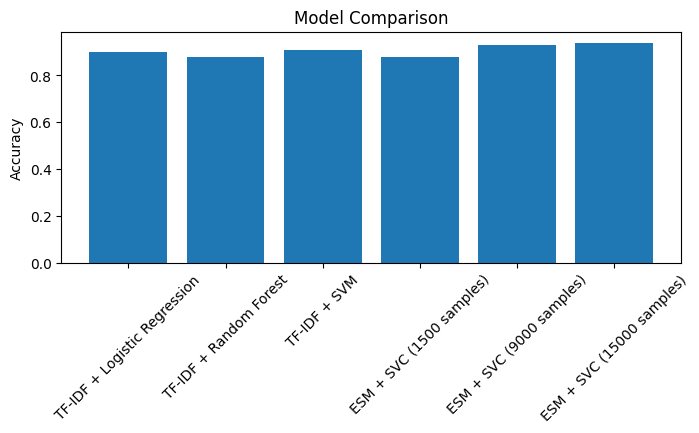

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))
plt.bar(df_compare["Model"], df_compare["Accuracy"])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

<Figure size 600x600 with 0 Axes>

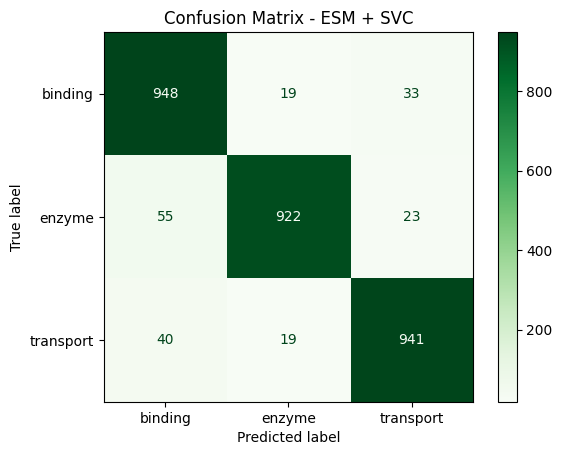

In [20]:
cm_esm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_esm,
    display_labels=["binding", "enzyme", "transport"]
)

disp.plot(cmap="Greens", values_format='d')

plt.title("Confusion Matrix - ESM + SVC")

plt.show()

In [21]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import numpy as np

# Best model
cv_model = SVC(kernel="linear")

# 5-fold cross-validation
scores = cross_val_score(
    cv_model,
    X_embeddings,
    y_labels,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross-Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())
print(f"Final Result: {scores.mean():.4f} ± {scores.std():.4f}")

Cross-Validation Scores: [0.93433333 0.94033333 0.93966667 0.93033333 0.93933333]
Mean Accuracy: 0.9368000000000001
Standard Deviation: 0.0038735570790223843
Final Result: 0.9368 ± 0.0039


In [22]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import numpy as np

# Best model
cv_model = SVC(kernel="linear")

# 5-fold cross-validation
scores = cross_val_score(
    cv_model,
    X_embeddings,
    y_labels,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross-Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())
print(f"Final Result: {scores.mean():.4f} ± {scores.std():.4f}")

Cross-Validation Scores: [0.93433333 0.94033333 0.93966667 0.93033333 0.93933333]
Mean Accuracy: 0.9368000000000001
Standard Deviation: 0.0038735570790223843
Final Result: 0.9368 ± 0.0039


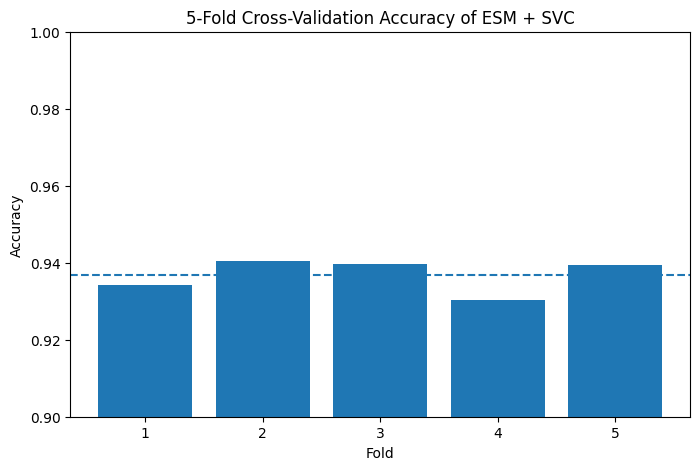

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), scores)
plt.axhline(scores.mean(), linestyle='--')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy of ESM + SVC")
plt.ylim(0.90, 1.00)
plt.show()